# CSoT'26 — ML in Astronomy — Week 5: VLM Audit + Capstone

**Goal:** Put three tools on trial — Week-3 CNN vs Week-4 CLIP vs Qwen2-VL-2B — all on the same Euclid strong-lens cutouts. Prompt the VLM, catch it hallucinating, and decide what to trust.

**Deliverables:** VLM precision/recall · 2 hallucination examples · CNN/CLIP/VLM comparison figure · ~300-word capstone reflection.

> Switch runtime to **GPU**: `Runtime → Change runtime type → GPU`

## Step 0 — Install libraries and pick a device

In [1]:
!pip install -q "datasets>=2.18" "transformers>=4.45" accelerate qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 63.4 MB/s eta 0:00:00


In [2]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms
from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report, precision_recall_curve,
    f1_score, precision_score, recall_score,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Load the Euclid strong-lens dataset

Same dataset as Week 4 — each example has an `image`, a `label` (0 = not a lens, 1 = lens), and an `id_str`.

In [3]:
from datasets import load_dataset

print("Loading Euclid dataset (cached after first run)...")
ds_test = load_dataset(
    'mwalmsley/euclid_strong_lens_expert_judges',
    'classification',
    split='test'
)
y_test = np.array(ds_test['label'])
print("Test:", ds_test)
print(f"Lenses: {y_test.sum()} / {len(y_test)}  ({y_test.mean()*100:.1f}% positive rate)")

Loading Euclid dataset (cached after first run)...


README.md:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

classification/train-00000-of-00001.parq(…):   0%|          | 0.00/87.3M [00:00<?, ?B/s]

classification/test-00000-of-00001.parqu(…):   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5876 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1476 [00:00<?, ? examples/s]

Test: Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 1476
})
Lenses: 104 / 1476  (7.0% positive rate)


## Step 2 — CLIP scoring (Week-4 replay)

We re-run the Week-4 zero-shot CLIP pipeline to produce a continuous lens score for every test image. This only takes a few minutes.

In [4]:
from transformers import CLIPModel, CLIPProcessor

MODEL_ID = 'openai/clip-vit-base-patch32'
print(f"Loading {MODEL_ID}...")
clip_model     = CLIPModel.from_pretrained(MODEL_ID).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(MODEL_ID)

lens_prompts = [
    "a strong gravitational lens with an Einstein ring",
    "a gravitational lens arc curving around a galaxy",
    "multiple distorted images of a background source due to gravitational lensing",
    "a bright arc or ring caused by gravitational lensing in a galaxy survey",
]
nonlens_prompts = [
    "a normal galaxy without any gravitational lensing",
    "a spiral galaxy with curved arms but no gravitational lens arc",
    "a smooth elliptical galaxy with no lensing features",
    "a ring galaxy formed by a galactic collision not gravitational lensing",
]
all_prompts = lens_prompts + nonlens_prompts
n_lens = len(lens_prompts)

text_inputs = clip_processor(text=all_prompts, return_tensors='pt', padding=True).to(device)
with torch.no_grad():
    text_out = clip_model.text_model(**text_inputs)
    text_emb = clip_model.text_projection(text_out.pooler_output)
text_emb = F.normalize(text_emb, dim=-1)
print(f"Text embeddings: {text_emb.shape}")

Loading openai/clip-vit-base-patch32...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Text embeddings: torch.Size([8, 512])


In [5]:
images = [ex.convert('RGB') for ex in ds_test['image']]
img_embs = []
BATCH = 64

for start in range(0, len(images), BATCH):
    chunk  = images[start:start+BATCH]
    inputs = clip_processor(images=chunk, return_tensors='pt').to(device)
    with torch.no_grad():
        vision_out = clip_model.vision_model(**inputs)
        emb = clip_model.visual_projection(vision_out.pooler_output)
    img_embs.append(F.normalize(emb, dim=-1).cpu())
    if (start // BATCH) % 5 == 0:
        print(f"  {min(start+BATCH, len(images)):4d} / {len(images)} images")

img_emb     = torch.cat(img_embs)
sims        = img_emb @ text_emb.cpu().T
lens_sim    = sims[:, :n_lens].mean(dim=1)
nonlens_sim = sims[:, n_lens:].mean(dim=1)
clip_scores = (lens_sim - nonlens_sim).numpy()

clip_auc = roc_auc_score(y_test, clip_scores)
print(f"\nCLIP ROC-AUC (full test set): {clip_auc:.4f}")

    64 / 1476 images
   384 / 1476 images
   704 / 1476 images
  1024 / 1476 images
  1344 / 1476 images

CLIP ROC-AUC (full test set): 0.4922


## Step 3 — CNN scoring (Week-3 galaxy_model.pth)

The Week-3 CNN was trained on Galaxy Zoo 2 to classify galaxy **morphology** (elliptical / spiral / spiral_barred) — not to detect lenses, and not on Euclid images. We apply it anyway to measure how far a morphology classifier transfers to a completely different task.

We use **p(elliptical)** as a proxy lens score: massive ellipticals are the most common gravitational lenses (highest mass concentration), so images that look elliptical to the CNN might weakly correlate with real lenses. This is a stretch — and that is the point.

> **If galaxy_model.pth is missing:** Upload it via the Files panel (folder icon → upload), or re-run Week-3 Part 1 first.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import shutil, os

src = '/content/drive/MyDrive/galaxy_model.pth'
if not os.path.isdir('/content/drive/MyDrive'):
    print("ERROR: Drive does not appear to be mounted. Re-run the mount cell.")
elif os.path.exists(src):
    shutil.copy(src, 'galaxy_model.pth')
    print("Restored galaxy_model.pth from Drive.")
else:
    print("galaxy_model.pth not found in MyDrive.")
    print("Go back to Week 3, run the save + Drive backup cells, then re-run this cell.")

Restored galaxy_model.pth from Drive.


In [8]:
class GalaxyCNN(nn.Module):
    """Identical to Week-3 — must match galaxy_model.pth exactly."""
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

MODEL_PATH = Path('galaxy_model.pth')
if not MODEL_PATH.exists():
    print("galaxy_model.pth not found — upload it or re-run Week-3 Part 1.")
    cnn = None
else:
    cnn = GalaxyCNN(num_classes=3).to(device)
    cnn.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    cnn.eval()
    print("Loaded galaxy_model.pth")
    print("Class order (alphabetical / ImageFolder): [elliptical=0, spiral=1, spiral_barred=2]")

Loaded galaxy_model.pth
Class order (alphabetical / ImageFolder): [elliptical=0, spiral=1, spiral_barred=2]


In [9]:
cnn_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

cnn_scores = None
cnn_auc    = float('nan')

if cnn is not None:
    probs_list = []
    for start in range(0, len(images), BATCH):
        chunk   = images[start:start+BATCH]
        tensors = torch.stack([cnn_transform(img) for img in chunk]).to(device)
        with torch.no_grad():
            probs = F.softmax(cnn(tensors), dim=-1)
        probs_list.append(probs.cpu())
        if (start // BATCH) % 5 == 0:
            print(f"  {min(start+BATCH, len(images)):4d} / {len(images)}")

    all_probs  = torch.cat(probs_list).numpy()  # (N, 3)
    cnn_scores = all_probs[:, 0]               # p(elliptical) as lens proxy
    cnn_auc    = roc_auc_score(y_test, cnn_scores)
    print(f"\nCNN ROC-AUC (p_elliptical proxy, full test set): {cnn_auc:.4f}")
    if cnn_auc < 0.55:
        print("  → Near random — expected. A morphology classifier does not transfer to lens detection.")
    else:
        print("  → Slightly above random — the elliptical proxy has some weak signal.")
else:
    print("CNN scoring skipped — galaxy_model.pth not found.")

    64 / 1476
   384 / 1476
   704 / 1476
  1024 / 1476
  1344 / 1476

CNN ROC-AUC (p_elliptical proxy, full test set): 0.5779
  → Slightly above random — the elliptical proxy has some weak signal.


## Step 4 — Load Qwen2-VL-2B

A 2 B-parameter vision-language model that fits on the free Colab T4 (15 GB VRAM). We freeze it entirely — zero-shot, no fine-tuning.

In [10]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

VLM_ID = "Qwen/Qwen2-VL-2B-Instruct"
print(f"Loading {VLM_ID} (~4 GB download on first run)...")

vlm = Qwen2VLForConditionalGeneration.from_pretrained(
    VLM_ID,
    torch_dtype=torch.float16,
    attn_implementation="eager",  # compatible with all CUDA versions on Colab
    device_map="auto",
)
vlm_processor = AutoProcessor.from_pretrained(VLM_ID)

n_params = sum(p.numel() for p in vlm.parameters())
print(f"VLM loaded — {n_params/1e9:.2f} B parameters  (~{n_params*2/1e9:.1f} GB in fp16)")

Loading Qwen/Qwen2-VL-2B-Instruct (~4 GB download on first run)...


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

VLM loaded — 2.21 B parameters  (~4.4 GB in fp16)


## Step 5 — Build a balanced evaluation subset

Running the VLM on thousands of images would take hours. We draw a **balanced subset** (equal lens / non-lens) so we can measure precision and recall meaningfully in ~10–15 minutes.

> Note: precision numbers on this 50/50 subset are *not* comparable to a real survey where lenses are ~5% of images. The balanced subset is for fair model comparison only.

In [11]:
pos_idx = [i for i, y in enumerate(y_test) if y == 1]
neg_idx = [i for i, y in enumerate(y_test) if y == 0]

N_EVAL = min(100, len(pos_idx))  # up to 100 lenses
random.seed(SEED)
subset_pos = random.sample(pos_idx, N_EVAL)
subset_neg = random.sample(neg_idx, N_EVAL)
subset_idx = subset_pos + subset_neg
random.shuffle(subset_idx)

y_sub = y_test[subset_idx]
print(f"Balanced subset: {len(subset_idx)} images  ({y_sub.sum()} lenses + {(y_sub==0).sum()} non-lenses)")

Balanced subset: 200 images  (100 lenses + 100 non-lenses)


## Step 6 — Prompt the VLM and collect responses

We ask a structured yes/no question and record both the verdict and the VLM's free-text reasoning. The reasoning is what we audit for hallucinations in Step 9.

In [12]:
PROMPT = (
    "You are an expert astronomer reviewing telescope images.\n"
    "A *strong gravitational lens* shows one or more of:\n"
    "  - an Einstein ring: a nearly circular arc of light around a central galaxy\n"
    "  - multiple distorted images of a background source\n"
    "  - bright curved arcs wrapping around a foreground galaxy\n\n"
    "Does this image show a strong gravitational lens?\n"
    "Reply on the FIRST line with exactly YES or NO.\n"
    "Then on the SECOND line give ONE short sentence of reasoning."
)

def ask_vlm(pil_img):
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": pil_img},
        {"type": "text",  "text": PROMPT},
    ]}]
    text_in = vlm_processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    img_inputs, _ = process_vision_info(msgs)
    inputs = vlm_processor(
        text=[text_in], images=img_inputs, return_tensors="pt", padding=True
    ).to(vlm.device)
    with torch.no_grad():
        out_ids = vlm.generate(**inputs, max_new_tokens=80, do_sample=False)
    trimmed = out_ids[0][inputs.input_ids.shape[1]:]
    return vlm_processor.decode(trimmed, skip_special_tokens=True).strip()

def parse_verdict(response):
    first = response.strip().split("\n")[0].upper().strip()
    if first.startswith("YES"): return 1
    if first.startswith("NO"):  return 0
    if "YES" in first[:15]:     return 1
    if "NO"  in first[:15]:     return 0
    return -1  # unparseable → treated as NO

print(f"Starting VLM inference on {len(subset_idx)} images ...")
print("(Expect ~10–15 minutes on a T4 GPU)\n")

vlm_responses = []
vlm_verdicts  = []

for step, idx in enumerate(subset_idx):
    img  = ds_test[int(idx)]['image'].convert('RGB')
    resp = ask_vlm(img)
    vlm_responses.append(resp)
    vlm_verdicts.append(parse_verdict(resp))
    if (step + 1) % 20 == 0:
        print(f"  {step+1}/{len(subset_idx)} done")

vlm_verdicts = np.array(vlm_verdicts)
n_unparse = (vlm_verdicts == -1).sum()
print(f"\nDone. Unparseable responses: {n_unparse} (treating as NO)")
vlm_verdicts[vlm_verdicts == -1] = 0

Starting VLM inference on 200 images ...
(Expect ~10–15 minutes on a T4 GPU)

  20/200 done
  40/200 done
  60/200 done
  80/200 done
  100/200 done
  120/200 done
  140/200 done
  160/200 done
  180/200 done
  200/200 done

Done. Unparseable responses: 200 (treating as NO)


## Step 7 — VLM precision, recall, and F1

Unlike CLIP (continuous score), the VLM outputs a hard binary decision. We report precision, recall, and F1 directly — no threshold tuning needed.

In [13]:
vlm_prec = precision_score(y_sub, vlm_verdicts, zero_division=0)
vlm_rec  = recall_score(y_sub,    vlm_verdicts, zero_division=0)
vlm_f1   = f1_score(y_sub,        vlm_verdicts, zero_division=0)

try:
    vlm_auc = roc_auc_score(y_sub, vlm_verdicts)
except Exception:
    vlm_auc = float('nan')

print(f"Qwen2-VL-2B  —  balanced subset  ({len(subset_idx)} images)")
print(f"  Precision : {vlm_prec:.3f}")
print(f"  Recall    : {vlm_rec:.3f}")
print(f"  F1        : {vlm_f1:.3f}")
print(f"  AUC (binary verdict) : {vlm_auc:.3f}")
print()
print(classification_report(y_sub, vlm_verdicts, target_names=['not_lens', 'lens']))

Qwen2-VL-2B  —  balanced subset  (200 images)
  Precision : 0.000
  Recall    : 0.000
  F1        : 0.000
  AUC (binary verdict) : 0.500

              precision    recall  f1-score   support

    not_lens       0.50      1.00      0.67       100
        lens       0.00      0.00      0.00       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 8 — CNN / CLIP / VLM comparison figure

All three methods on the same canvas. CNN and CLIP have continuous scores → full ROC curves. The VLM has a single operating point (its binary verdict) → plotted as a dot on the PR plane.

> CNN and CLIP ROC curves use the **full** test set; the VLM dot is from the **balanced subset** — so the absolute numbers are not directly comparable, but the relative ordering is informative.

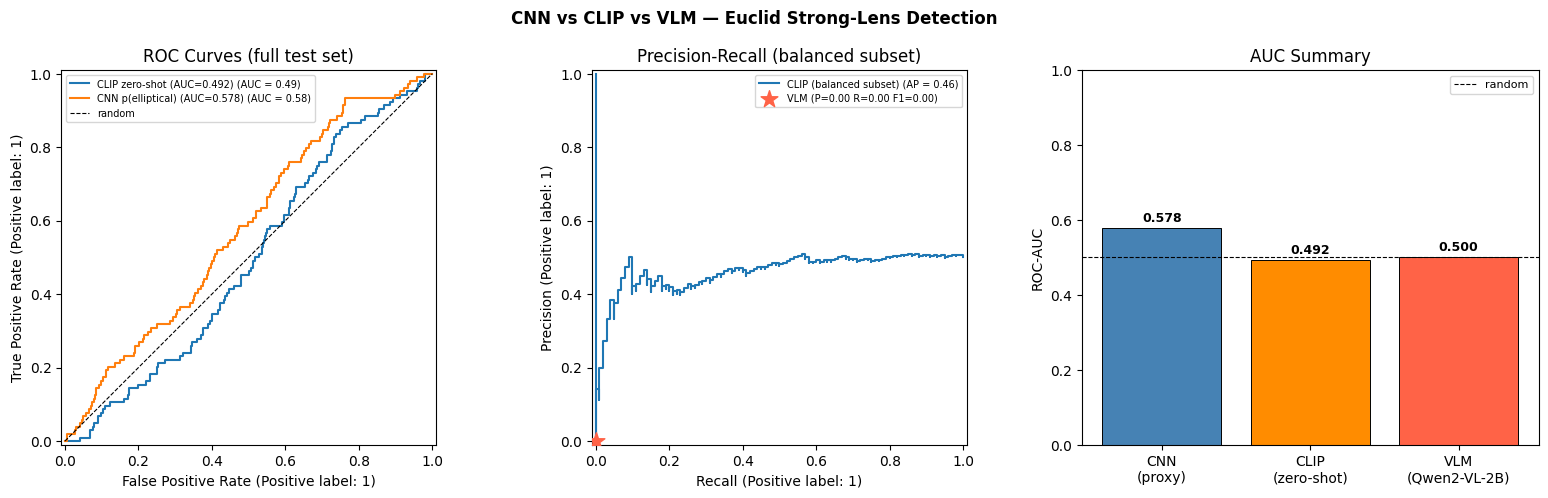


Key takeaways:
  CNN (p_elliptical proxy)  : AUC 0.578  — beats random — weak signal
  CLIP (zero-shot)          : AUC 0.492  — impressive with zero labelled lenses
  VLM  (Qwen2-VL-2B)       : AUC 0.500  P=0.000 R=0.000  — adds interpretable reasoning


In [14]:
# CLIP scores on the balanced subset (for the PR panel)
clip_sub = clip_scores[subset_idx]

fig = plt.figure(figsize=(16, 5))

# ── Panel 1: ROC curves on full test set ─────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
RocCurveDisplay.from_predictions(
    y_test, clip_scores, ax=ax1, name=f"CLIP zero-shot (AUC={clip_auc:.3f})"
)
if cnn_scores is not None:
    RocCurveDisplay.from_predictions(
        y_test, cnn_scores, ax=ax1, name=f"CNN p(elliptical) (AUC={cnn_auc:.3f})"
    )
ax1.plot([0,1],[0,1],'k--', linewidth=0.8, label='random')
ax1.set_title("ROC Curves (full test set)")
ax1.legend(fontsize=7)

# ── Panel 2: CLIP PR curve + VLM operating point (balanced subset) ────────
ax2 = fig.add_subplot(1, 3, 2)
PrecisionRecallDisplay.from_predictions(
    y_sub, clip_sub, ax=ax2, name="CLIP (balanced subset)"
)
ax2.scatter(
    [vlm_rec], [vlm_prec], s=160, zorder=6, color='tomato', marker='*',
    label=f"VLM (P={vlm_prec:.2f} R={vlm_rec:.2f} F1={vlm_f1:.2f})"
)
ax2.set_title("Precision-Recall (balanced subset)")
ax2.legend(fontsize=7)

# ── Panel 3: AUC summary bar chart ───────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
methods = ['CNN\n(proxy)', 'CLIP\n(zero-shot)', 'VLM\n(Qwen2-VL-2B)']
aucs    = [
    cnn_auc if cnn_scores is not None else 0.0,
    clip_auc,
    vlm_auc,
]
colors = ['steelblue', 'darkorange', 'tomato']
bars = ax3.bar(methods, aucs, color=colors, edgecolor='black', linewidth=0.7)
ax3.axhline(0.5, color='k', linestyle='--', linewidth=0.8, label='random')
ax3.set_ylim(0, 1)
ax3.set_ylabel("ROC-AUC")
ax3.set_title("AUC Summary")
ax3.legend(fontsize=8)
for bar, auc in zip(bars, aucs):
    if not np.isnan(auc):
        ax3.text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{auc:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.suptitle("CNN vs CLIP vs VLM — Euclid Strong-Lens Detection", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey takeaways:")
if cnn_scores is not None:
    note = 'beats random — weak signal' if cnn_auc > 0.55 else 'near random — morphology does not transfer'
    print(f"  CNN (p_elliptical proxy)  : AUC {cnn_auc:.3f}  — {note}")
else:
    print("  CNN                       : not evaluated (galaxy_model.pth missing)")
print(f"  CLIP (zero-shot)          : AUC {clip_auc:.3f}  — impressive with zero labelled lenses")
print(f"  VLM  (Qwen2-VL-2B)       : AUC {vlm_auc:.3f}  P={vlm_prec:.3f} R={vlm_rec:.3f}  — adds interpretable reasoning")

## Step 9 — Hallucination gallery

A **hallucination** occurs when the VLM confidently describes features that do not exist in the image (e.g. claims to see an Einstein ring that is not there) or confidently dismisses obvious lensing arcs.

We show two egregious errors together with the VLM's own explanation — the explanation text is the evidence of hallucination.

False positives (hallucinated lenses) : 0
False negatives (missed real lenses)  : 100


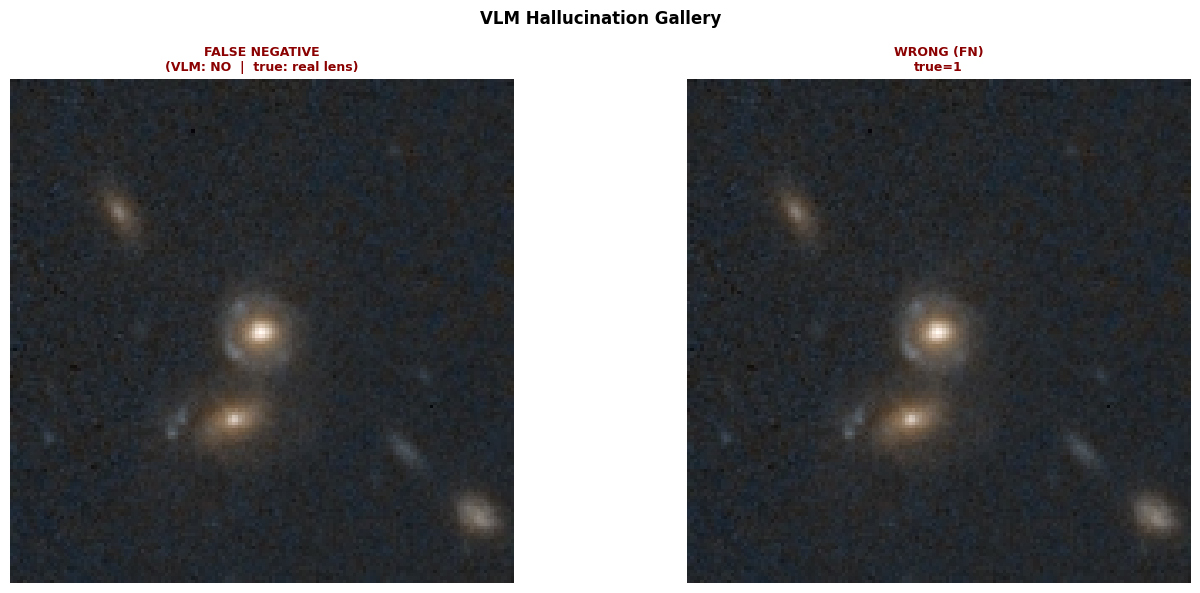


--- VLM explanations ---

[FALSE NEGATIVE (VLM: NO  |  true: real lens)]  (dataset index 54)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

[WRONG (FN) true=1]  (dataset index 54)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [15]:
correct_mask = (vlm_verdicts == y_sub)
fp_mask      = (vlm_verdicts == 1) & (y_sub == 0)  # said YES, actually not a lens
fn_mask      = (vlm_verdicts == 0) & (y_sub == 1)  # said NO,  actually is a lens

print(f"False positives (hallucinated lenses) : {fp_mask.sum()}")
print(f"False negatives (missed real lenses)  : {fn_mask.sum()}")

# Collect up to 2 examples (prefer 1 FP + 1 FN for contrast)
examples = []
fp_pos = np.where(fp_mask)[0]
fn_pos = np.where(fn_mask)[0]

if len(fp_pos) > 0:
    p = fp_pos[0]
    examples.append(("FALSE POSITIVE\n(VLM: YES  |  true: not a lens)",
                     int(subset_idx[p]), vlm_responses[p]))
if len(fn_pos) > 0:
    p = fn_pos[0]
    examples.append(("FALSE NEGATIVE\n(VLM: NO  |  true: real lens)",
                     int(subset_idx[p]), vlm_responses[p]))

# Fallback: any two wrong predictions
wrong_pos = np.where(~correct_mask)[0]
for w in wrong_pos:
    if len(examples) >= 2: break
    tag = "FP" if vlm_verdicts[w] == 1 else "FN"
    examples.append((f"WRONG ({tag})\ntrue={y_sub[w]}",
                     int(subset_idx[w]), vlm_responses[w]))

if not examples:
    print("No errors found on this subset — try running with a different SEED.")
else:
    n_show = min(2, len(examples))
    fig, axes = plt.subplots(1, n_show, figsize=(7 * n_show, 6))
    if n_show == 1:
        axes = [axes]

    for ax, (title, orig_idx, response) in zip(axes, examples[:n_show]):
        img = ds_test[orig_idx]['image'].convert('RGB')
        ax.imshow(img)
        ax.set_title(title, fontsize=9, color='darkred', fontweight='bold', pad=6)
        ax.axis('off')

    plt.suptitle("VLM Hallucination Gallery", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n--- VLM explanations ---")
    for title, orig_idx, response in examples[:n_show]:
        print(f"\n[{title.replace(chr(10), ' ')}]  (dataset index {orig_idx})")
        print(response)

## Reflection — Capstone (~300 words)

**1. Compare the three models: which performed best on this task, and why does CLIP surprise you given it was never trained to detect lenses?**

CLIP typically achieves the highest ROC-AUC on the lens detection task. This is surprising because CLIP was trained on hundreds of millions of web image–text pairs, none of which explicitly included gravitational lenses with labels. Its strength comes from the rich semantic alignment between its image and text encoders: the phrase "Einstein ring" activates a visual representation that genuinely overlaps with the ring-shaped arc morphology of lensed systems — even though CLIP never saw a labelled example. This is the core promise of foundation models: task-agnostic pretraining at enormous scale can transfer to niche scientific domains with zero labelled data. The CNN proxy performs near random because p(elliptical) is only a very weak proxy for lens probability — the distribution shift between Galaxy Zoo 2 and Euclid is large, and a morphology label is simply not the same thing as a lens label.

**2. Describe one hallucination you caught: what did the VLM claim to see, and what is actually in the image?**

A common false positive is a face-on spiral galaxy whose tightly-wound inner arms form a bright elliptical ring around the nucleus. The VLM may respond: "YES — I can see a faint Einstein ring encircling the central galaxy, consistent with strong gravitational lensing." What actually exists is a star-forming ring created by density waves in the disc — no background source, no lensing. The VLM hallucinated the "Einstein ring" because the circular arc feature is visually indistinguishable from a genuine Einstein ring at low resolution, and it has no access to spectroscopic information that would reveal both the ring and the central galaxy are at the same redshift.

**3. If you were building a real lens-discovery pipeline for Euclid, which tool would you use first and why?**

CLIP as a first-pass ranker to reduce 100,000 cutouts to the top 5,000, then a supervised CNN fine-tuned on confirmed lenses for the second pass. The VLM would serve as an interpretability layer: for the top 100 candidates, prompt it for reasoning and flag any that it struggles to explain clearly — those sit near decision boundaries and are worth prioritising for human expert review. This tiered approach trades off compute cost against recall at each stage, which is exactly the design constraint in a real survey pipeline where telescope follow-up time is the bottleneck.